<a href="https://colab.research.google.com/github/LeonardooAlves/WM9G1-BDAI/blob/main/Week%202/2_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression: From Preprocessing to Hyperparameter Tuning
**MSc Engineering Business Management — Big Data Analytics for Industry**

In this notebook we will work through a **complete classification pipeline** using the UCI Bank Marketing dataset. A Portuguese bank ran telephone campaigns to convince clients to subscribe to a term deposit. Our job is to predict whether a client will subscribe (`yes`) or not (`no`).

This is a **binary classification** problem — the model must assign each client to one of two classes. Logistic regression is one of the most widely used algorithms for this type of task because it is fast to train, easy to interpret, and produces probability estimates that can be used to make business decisions.

**What we will cover:**
1. **Loading and exploring the data (EDA)** — understanding what the data looks like before building any model
2. **Preprocessing for machine learning** — encoding, splitting, and scaling so the algorithm can learn effectively
3. **Building a baseline Logistic Regression model** — establishing a starting point with default settings
4. **Evaluating the model with multiple metrics** — going beyond accuracy to understand where the model succeeds and fails
5. **Hyperparameter tuning with Grid Search** — systematically finding the best regularisation settings
6. **Optimising the decision threshold** — adjusting the probability cutoff to align with business priorities

## 1. Data Understanding

Before we begin any analysis, we need to import the Python libraries we will use throughout the notebook and load our dataset. The dataset has been uploaded to Google Colab as `banking.csv`.

Let's import the libraries and load the data. We use **pandas** for data manipulation, **numpy** for numerical operations, **matplotlib** and **seaborn** for visualisation, and **scikit-learn** for machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
# Load the dataset
df = pd.read_csv("banking.csv")
print("Loaded:", df.shape)

Loaded: (41188, 21)


There is 41188 rows and 21 columns.

Now, let's take peek into the dataset `df`.

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,210,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,138,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,339,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,185,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,137,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

Input variables

- age (numeric)
- job : type of job (categorical: “admin”, “blue-collar”, “entrepreneur”, “housemaid”, “management”, “retired”, “self-employed”, “services”, “student”, “technician”, “unemployed”, “unknown”)
- marital : marital status (categorical: “divorced”, “married”, “single”, “unknown”)
- education (categorical: “basic.4y”, “basic.6y”, “basic.9y”, “high.school”, “illiterate”, “professional.course”, “university.degree”, “unknown”)
- default: has credit in default? (categorical: “no”, “yes”, “unknown”)
- housing: has housing loan? (categorical: “no”, “yes”, “unknown”)
- loan: has personal loan? (categorical: “no”, “yes”, “unknown”)
- contact: contact communication type (categorical: “cellular”, “telephone”)
- month: last contact month of year (categorical: “jan”, “feb”, “mar”, …, “nov”, “dec”)
- day_of_week: last contact day of the week (categorical: “mon”, “tue”, “wed”, “thu”, “fri”)
- duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). The duration is not known before a call is performed, also, after the end of the call, y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model
- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
- previous: number of contacts performed before this campaign and for this client (numeric)
- poutcome: outcome of the previous marketing campaign (categorical: “failure”, “nonexistent”, “success”)
-emp.var.rate: employment variation rate — (numeric)
- cons.price.idx: consumer price index — (numeric)
- cons.conf.idx: consumer confidence index — (numeric)
- euribor3m: euribor 3 month rate — (numeric)
- nr.employed: number of employees — (numeric)


Predict variable (desired target):
- y — has the client subscribed a term deposit? (binary: “1”, means “Yes”, “0” means “No”)

Check for missing values:

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical first step in any machine learning project. Before building a model, we need to understand the structure, distributions, and relationships in the data. EDA helps us identify potential issues such as missing values, class imbalance, skewed distributions, and correlated features — all of which affect how we preprocess the data and which metrics we should trust.

### 2.1 First Look at the Data

We begin by examining summary statistics for the numeric features. `df.describe()` gives us the count, mean, standard deviation, minimum, maximum, and quartile values for each numeric column. This helps us spot unusual ranges (e.g. `pdays = 999` likely represents "never contacted before") and understand the typical scale of each feature.

In [ ]:
# Summary statistics for numeric columns
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


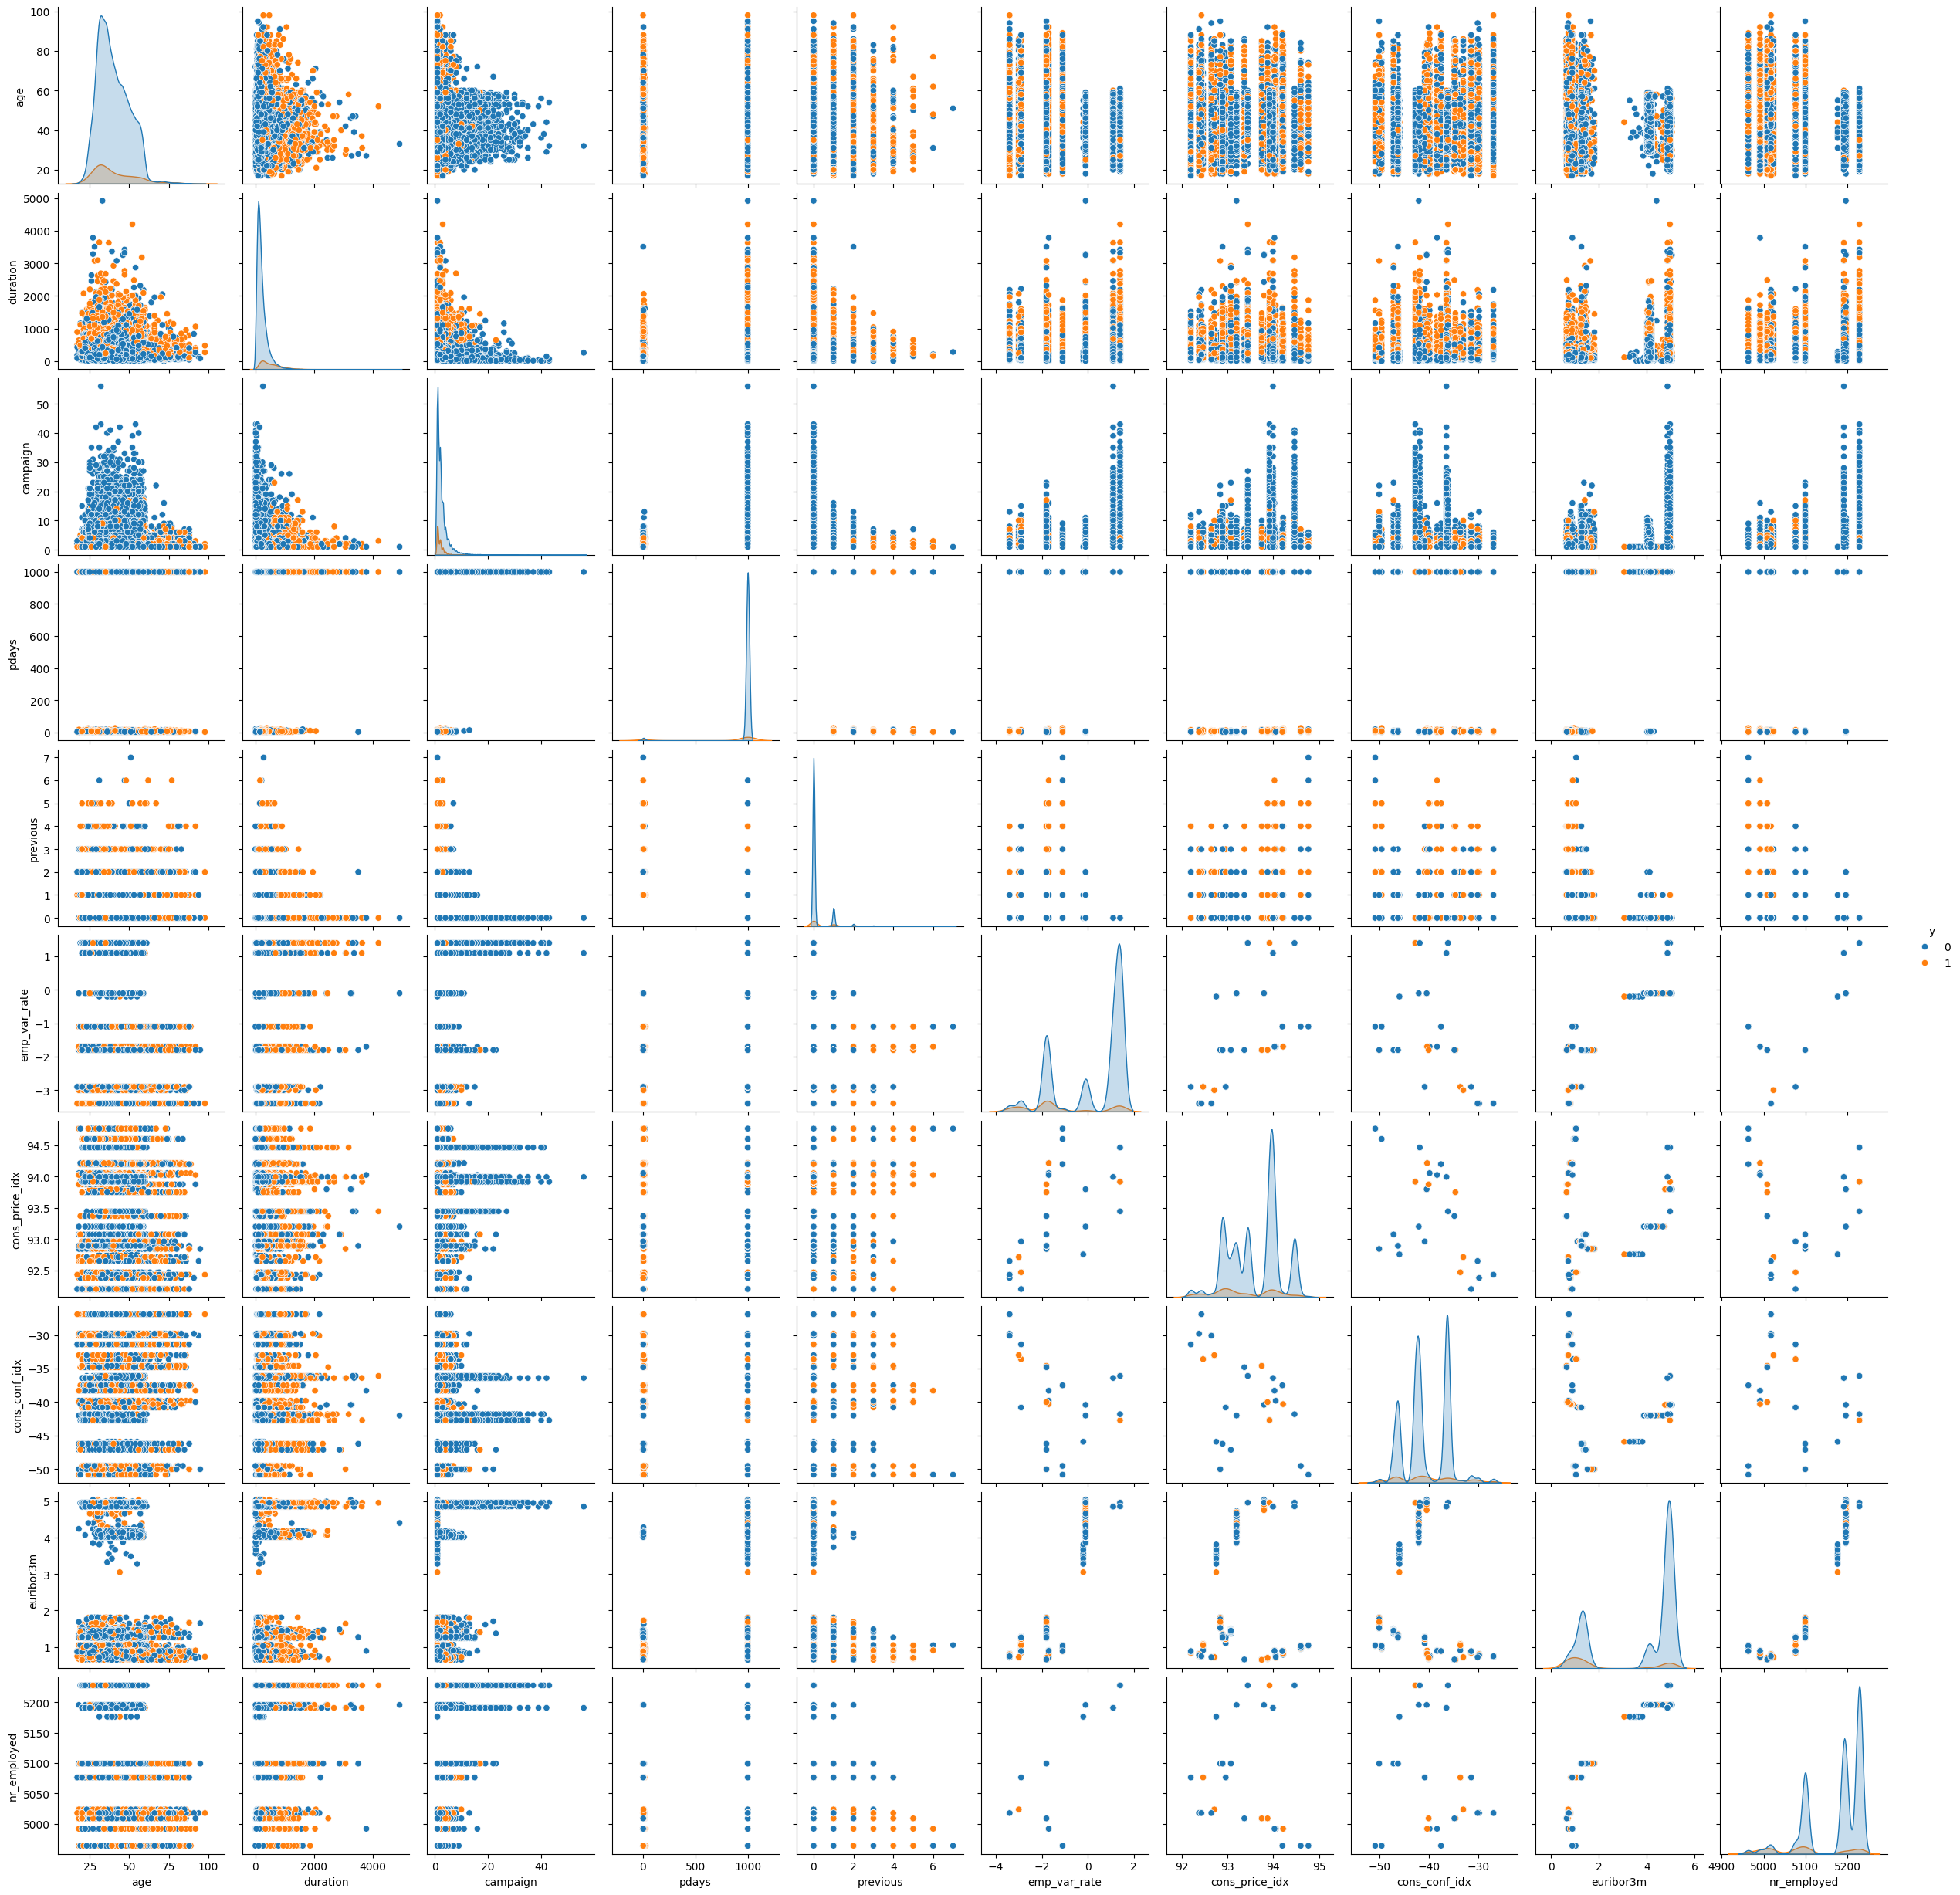

In [ ]:
sns.pairplot(df, hue='y')
plt.show()

### 2.2 Target Variable Distribution

Before modelling, we need to understand our **response variable** — the column we are trying to predict. The most important question is: **is the dataset balanced or imbalanced?**

A dataset is **balanced** when both classes have roughly equal numbers of observations (e.g. 50/50 or 60/40). It is **imbalanced** when one class heavily outnumbers the other (e.g. 90/10). This distinction matters because it directly affects which evaluation metrics we should trust and whether the model can learn the minority class effectively.

The cell below counts how many clients subscribed (`y = 1`) versus did not subscribe (`y = 0`), and shows the proportions. If the positive class makes up less than ~20% of the data, we have a meaningful class imbalance that we need to account for during evaluation.

In [ ]:
# Count of each class
print(df['y'].value_counts())
print()
print('Proportions:')
print(df['y'].value_counts(normalize=True).round(3))

y
0    36548
1     4640
Name: count, dtype: int64

Proportions:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


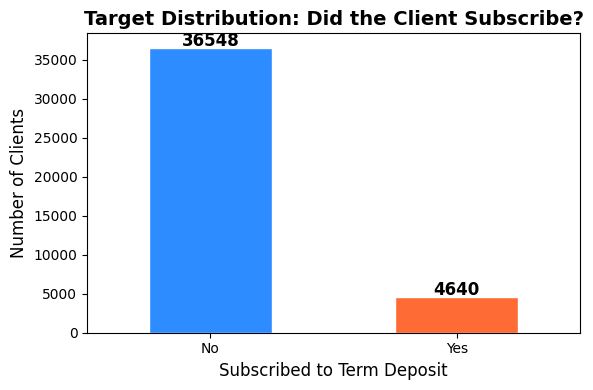

The dataset is IMBALANCED — roughly 89% "no" vs 11% "yes".
This means accuracy alone will be misleading!


In [ ]:
# Visualise the class distribution
fig, ax = plt.subplots(figsize=(6, 4))

colours = ['#2D8CFF', '#FF6B35']
df['y'].value_counts().plot(kind='bar', color=colours, edgecolor='white', ax=ax)

ax.set_title('Target Distribution: Did the Client Subscribe?', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscribed to Term Deposit', fontsize=12)
ax.set_ylabel('Number of Clients', fontsize=12)
ax.set_xticklabels(['No', 'Yes'], rotation=0)

# Add count labels on bars
for i, v in enumerate(df['y'].value_counts()):
    ax.text(i, v + 200, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print('The dataset is IMBALANCED — roughly 89% "no" vs 11% "yes".')
print('This means accuracy alone will be misleading!')

### 2.3 Feature Overview

The dataset contains both **numeric** (quantitative) and **categorical** (qualitative) features. Understanding the type of each feature is essential because it determines how we preprocess it:

- **Numeric features** (e.g. `age`, `duration`, `campaign`) can be fed directly into the model after scaling.
- **Categorical features** (e.g. `job`, `marital`, `education`) must first be converted into numbers using encoding techniques such as one-hot encoding.

The cell below identifies which columns belong to each type. The histograms that follow show the **distribution** of key numeric features. When interpreting these histograms, look for:
- **Skewness** — Are values concentrated on one side? (e.g. `duration` is likely right-skewed: most calls are short, but a few are very long)
- **Unusual spikes** — Does a value appear far more often than expected? (e.g. `pdays = 999` is a placeholder for "client was never previously contacted")
- **Range differences** — Features like `age` (17–98) and `nr_employed` (4963–5228) live on very different scales, which is why scaling will be important later

In [ ]:
# Identify column types from the FEATURES only (not including target)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features ({len(numeric_cols)}):    {numeric_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

Numeric features (11):    ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


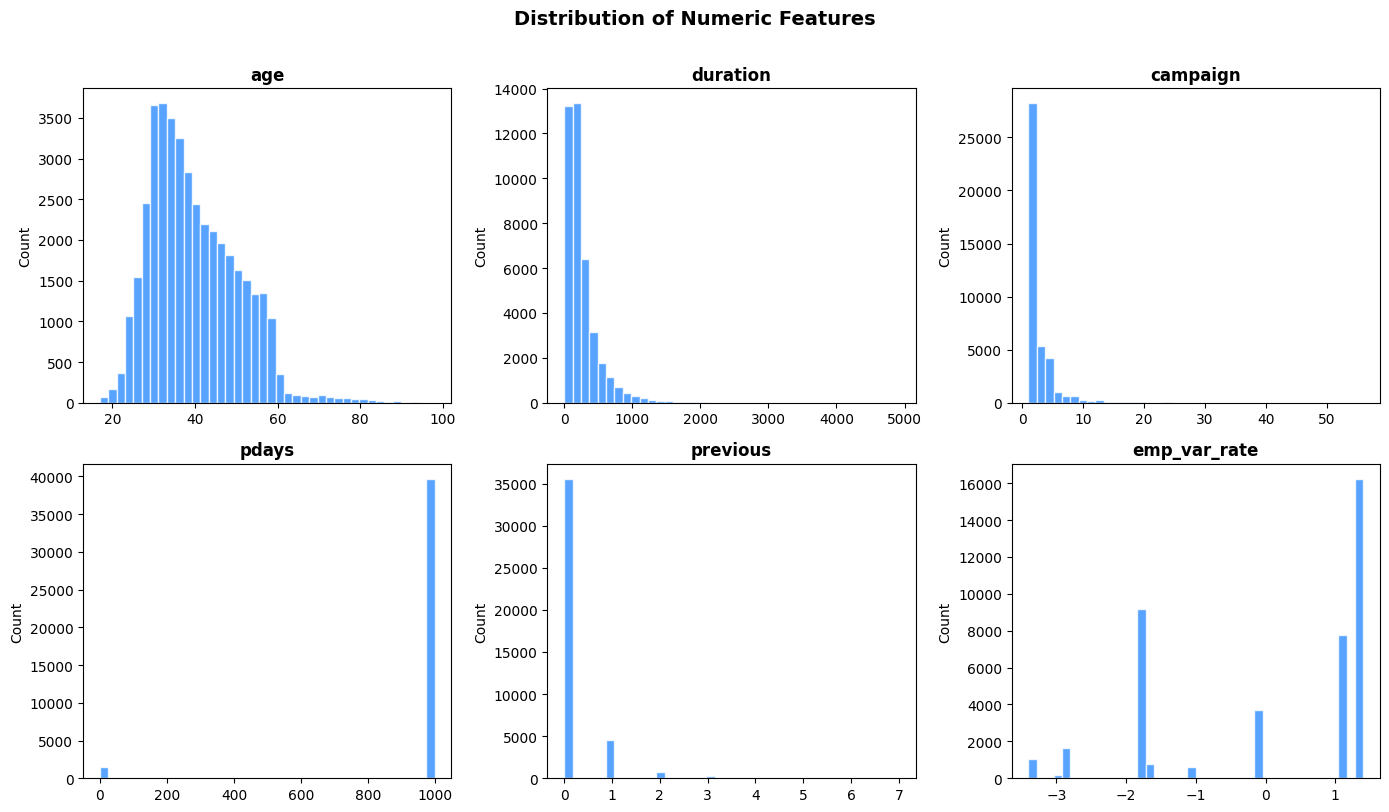

In [ ]:
# Distribution of key numeric features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

plot_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate']

for i, col in enumerate(plot_cols):
    row, col_idx = i // 3, i % 3
    axes[row, col_idx].hist(df[col], bins=40, color='#2D8CFF', edgecolor='white', alpha=0.8)
    axes[row, col_idx].set_title(col, fontsize=12, fontweight='bold')
    axes[row, col_idx].set_ylabel('Count')

plt.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

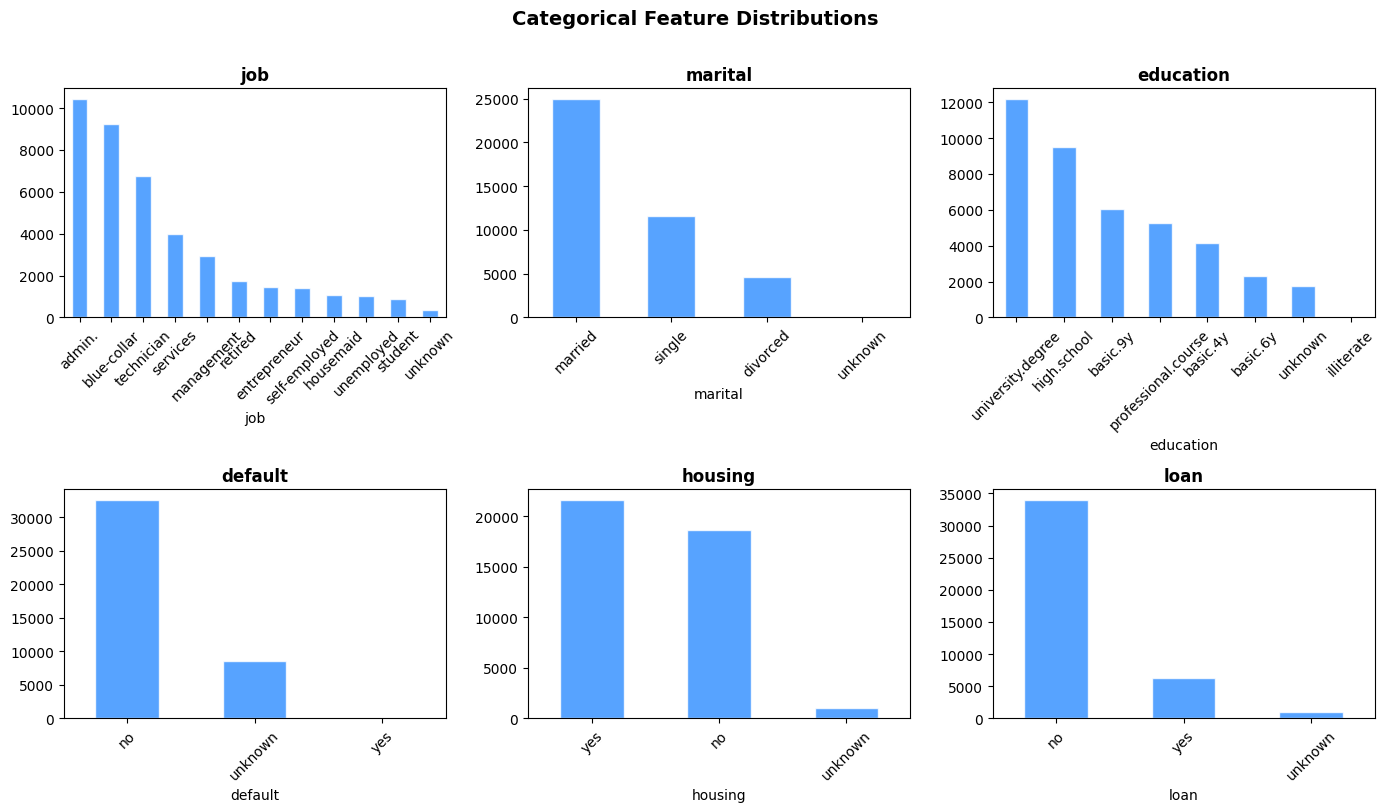

In [ ]:
# Look at categorical features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

cat_to_plot = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for i, col in enumerate(cat_to_plot):
    row, col_idx = i // 3, i % 3
    df[col].value_counts().plot(kind='bar', ax=axes[row, col_idx],
                                 color='#2D8CFF', edgecolor='white', alpha=0.8)
    axes[row, col_idx].set_title(col, fontsize=12, fontweight='bold')
    axes[row, col_idx].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
#check Education
df["education"].unique()

array(['basic.4y', 'unknown', 'university.degree', 'high.school',
       'basic.9y', 'professional.course', 'basic.6y', 'illiterate'],
      dtype=object)

In [ ]:
# Only run this if the column exists
df["education"] = df["education"].replace(
        {"basic.4y": "Basic", "basic.6y": "Basic", "basic.9y": "Basic"}
)
print("Education categories after grouping:")
print(df["education"].value_counts().head(6))

Education categories after grouping:
education
Basic                  12513
university.degree      12168
high.school             9515
professional.course     5243
unknown                 1731
illiterate                18
Name: count, dtype: int64


### 2.4 Relationship with the Target

Now we explore how each feature relates to the target variable. This helps us understand **which features might be useful predictors** and gives us early intuition about the model's behaviour.

**Grouped means** (the table below) show the average value of each numeric feature separately for clients who subscribed (`y=1`) and those who did not (`y=0`). Large differences between the two groups suggest that a feature carries predictive signal.

**The correlation heatmap** shows pairwise linear correlations between all numeric features. Values close to **+1 or –1** indicate strong linear relationships. There are two things to watch for:

1. **Correlation with the target (`y`):** Features with higher absolute correlation with `y` are likely to be stronger predictors. These are worth keeping in the model.

2. **Correlation between features (multicollinearity):** When two predictor features are highly correlated with each other (e.g. `euribor3m` and `emp_var_rate`), they carry redundant information. In logistic regression, **multicollinearity** inflates the variance of the estimated coefficients, making them unreliable and difficult to interpret. While it does not necessarily reduce prediction accuracy, it makes the individual feature weights unstable — small changes in the data can cause large swings in the coefficients. In practice, you can address this by removing one of the correlated features, using regularisation (L1/L2), or applying dimensionality reduction techniques like PCA.

**The cross-tabulation bar charts** below show how the subscription rate varies across different categories of `job`, `marital status`, and `education`. These plots help identify which groups are more receptive to the bank's campaign — valuable information for both feature engineering and business strategy.

In [ ]:
# Mean of numeric features grouped by target
grouped = df[numeric_cols].groupby('y').mean()
display(grouped)

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
y,,,,,,,,,,
0,39.911185,220.844807,2.633085,984.113878,0.132374,0.248875,93.603757,-40.593097,3.811491,5176.166600
1,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991


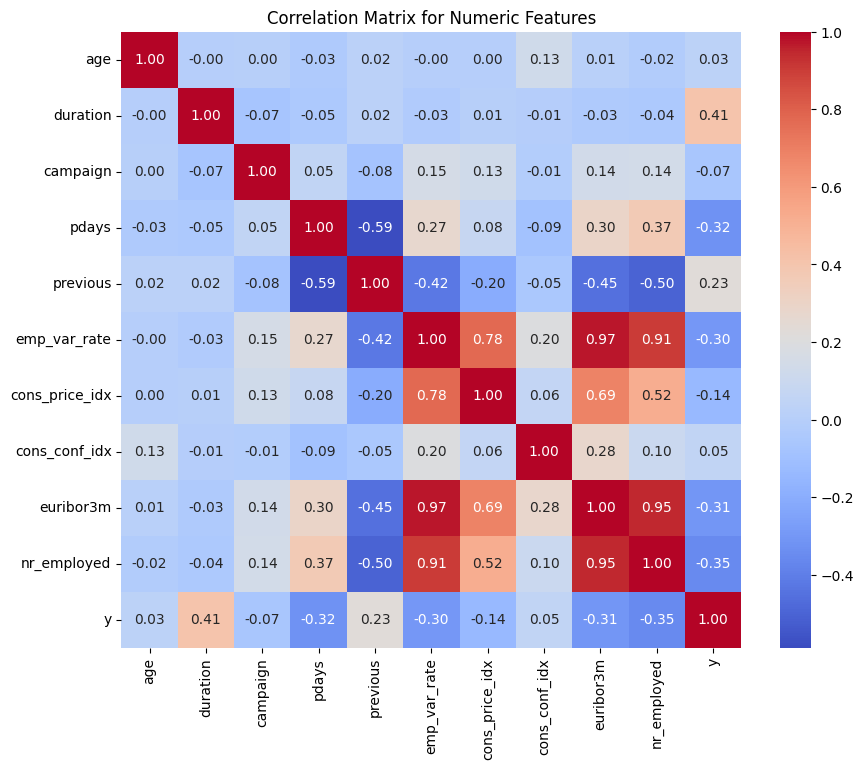

In [ ]:
# Calculate the correlation matrix for numeric features
corr_matrix = df[numeric_cols].corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix for Numeric Features')
plt.show()

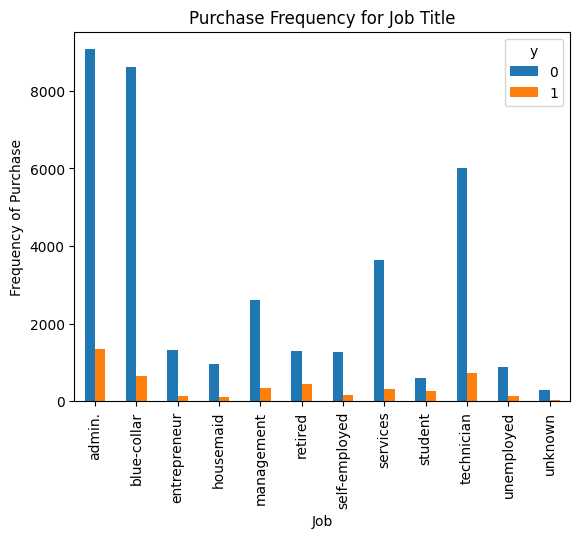

In [ ]:
pd.crosstab(df.job,df.y).plot(kind='bar')
plt.title('Purchase Frequency for Job Title')
plt.xlabel('Job')
plt.ylabel('Frequency of Purchase')
plt.savefig('purchase_fre_job')

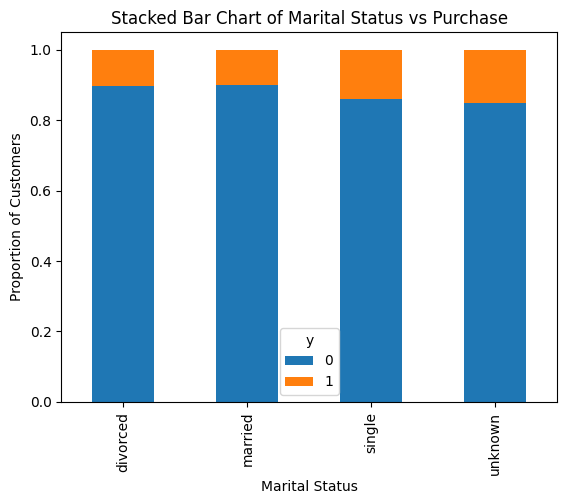

In [ ]:
table=pd.crosstab(df.marital,df.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Chart of Marital Status vs Purchase')
plt.xlabel('Marital Status')
plt.ylabel('Proportion of Customers')
plt.savefig('mariral_vs_pur_stack')

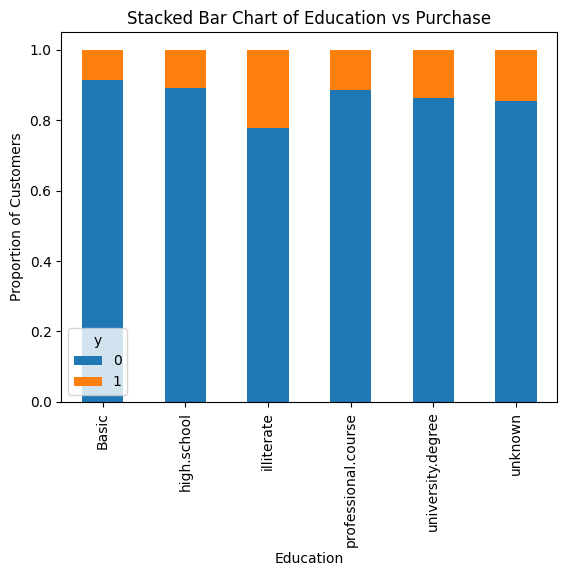

In [ ]:
table=pd.crosstab(df.education,df.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Chart of Education vs Purchase')
plt.xlabel('Education')
plt.ylabel('Proportion of Customers')
plt.savefig('edu_vs_pur_stack')

## 3. Data Preprocessing

Machine learning algorithms, including logistic regression, require data in a specific format before training. Raw datasets typically contain categorical text, features on different scales, and a mix of feature and target columns. Preprocessing transforms the data into a format the algorithm can work with effectively.

In this section we will carry out four essential preprocessing steps:

1. **Separate features from the target** — isolate what the model will learn from (X) and what it will predict (y)
2. **Encode categorical features** — convert text categories into numeric columns using one-hot encoding
3. **Split the data** — divide into training and test sets to enable honest evaluation
4. **Scale numeric features** — standardise values so regularisation treats all features fairly

### 3.1 Separate Features and Target

The first preprocessing step is to separate the **feature matrix** `X` (the input columns the model learns from) and the **target vector** `y` (the outcome the model predicts). This is important because we must ensure that the target variable is never included in the feature set — otherwise the model would have direct access to the answer and achieve artificially perfect performance.

In our dataset, the target column `y` is already encoded as integers: `0` = did not subscribe, `1` = subscribed. We therefore do not need to map text labels to numbers.

In [ ]:
# ── Separate features (X) and target (y) ──
y = df['y']
X = df.drop(columns=['y'])

print(f'Features (X): {X.shape}')
print(f'Target (y):   {y.shape}  — already encoded as 0 and 1')

Features (X): (41188, 20)
Target (y):   (41188,)  — already encoded as 0 and 1


### 3.2 Encode Categorical Features

Logistic regression (and most scikit-learn algorithms) requires all input features to be **numeric**. Categorical columns like `job`, `marital`, and `education` contain text labels, so we need to convert them into numbers.

**One-hot encoding** is the standard approach. It creates a new binary (0/1) column for each unique category. For example, the `marital` column with values `{married, single, divorced}` becomes three columns:

| Original | marital_married | marital_single | marital_divorced |
|---|---|---|---|
| married | 1 | 0 | 0 |
| single | 0 | 1 | 0 |
| divorced | 0 | 0 | 1 |

We use `pd.get_dummies(X, columns=categorical_cols, drop_first=True)` to perform this encoding. The **`drop_first=True`** parameter is critical — it drops the first category from each feature (e.g. keeps `marital_single` and `marital_divorced` but drops `marital_married`). This avoids the **dummy variable trap**, a form of multicollinearity where the dropped column is perfectly predictable from the remaining columns (if a person is not single and not divorced, they must be married). Without `drop_first=True`, the feature matrix would contain redundant information that can destabilise the model's coefficient estimates.

In [ ]:
# One-hot encode all categorical columns in X (features only)
# drop_first=True avoids the 'dummy variable trap' (multicollinearity)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f'Original features: {X.shape[1]}')
print(f'After one-hot encoding: {X_encoded.shape[1]}')
print(f'\nNew columns (first 10): {X_encoded.columns.tolist()[:10]}')
X_encoded.head()

Original features: 20
After one-hot encoding: 51

New columns (first 10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']


,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,44,210,1,999,0,1.4,93.444,-36.1,4.963,5228.1,True,False,...,False,False,False,False,False,False,False,True,False,False,True,False
1,53,138,1,999,0,-0.1,93.200,-42.0,4.021,5195.8,False,False,...,False,False,False,True,False,False,False,False,False,False,True,False
2,28,339,3,6,2,-1.7,94.055,-39.8,0.729,4991.6,False,False,...,True,False,False,False,False,False,False,True,False,False,False,True
3,39,185,2,999,0,-1.8,93.075,-47.1,1.405,5099.1,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False
4,55,137,1,3,1,-2.9,92.201,-31.4,0.869,5076.2,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True


### 3.3 Train-Test Split

We split the data into a **training set** (80%) and a **test set** (20%) before any further preprocessing. The order of operations here is crucial.

**What is data leakage?**

Data leakage occurs when information from the test set "leaks" into the training process, giving the model an unfair advantage. If this happens, the model's performance on the test set will be **overly optimistic** — it will look better in evaluation than it actually performs on truly unseen data. This defeats the entire purpose of having a test set.

Common sources of leakage include:
- **Scaling before splitting:** If you compute the mean and standard deviation from the entire dataset (including test data) and then split, the training set has been influenced by test set statistics.
- **Feature engineering before splitting:** Creating features (e.g. aggregates, encodings) using the full dataset means the training set "knows" about test set patterns.
- **Target leakage:** Including features that are derived from or directly correlated with the target in a way that would not be available at prediction time.

**How we prevent leakage here:**
1. We split **first**, then scale — the scaler is fitted on training data only
2. We use `stratify=y` to ensure both the training and test sets have the **same proportion** of subscribers and non-subscribers as the original dataset. Without stratification, random splitting could give us a test set with a very different class balance, making evaluation unreliable.
3. We use `random_state=42` to make the split **reproducible** — running the notebook again will produce the same train/test partition.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # keep class proportions in both sets
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nClass proportions (train): {y_train.mean():.3f}')
print(f'Class proportions (test):  {y_test.mean():.3f}')

Training set: 32950 samples
Test set:     8238 samples

Class proportions (train): 0.113
Class proportions (test):  0.113


### 3.4 Scale Numeric Features

**Why do we need to scale numeric features?**

Numeric features in our dataset have very different ranges. For example, `age` ranges from 17 to 98, while `nr_employed` ranges from 4,963 to 5,228, and `euribor3m` ranges from 0.6 to 5.0. When features live on different scales, two problems arise:

1. **Regularisation becomes unfair.** Logistic regression with L1 or L2 regularisation adds a penalty based on the size of the feature weights. If a feature has a large numeric range (like `nr_employed`), its weight will naturally be small even if the feature is important. The penalty would then disproportionately shrink the weights of small-range features. Scaling puts all features on the same footing so the penalty is applied equally.

2. **Gradient descent converges slowly.** The optimisation algorithm that trains the model takes smaller, more efficient steps when features are on similar scales. Without scaling, training can be slow or unstable.

We use **`StandardScaler`**, which transforms each feature to have **mean = 0** and **standard deviation = 1** using the formula:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

where $\mu$ is the mean and $\sigma$ is the standard deviation, both computed from the **training set only**.

**Important:** We **fit** the scaler on the training data (`fit_transform`) and then only **transform** the test data (`transform`) using the same learned mean and standard deviation. If we fitted the scaler on the test data too, we would introduce data leakage. We also only scale the original numeric columns — the one-hot encoded binary columns (0/1) are already on an appropriate scale.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then transform both sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ensure 'y' is not in numeric_cols when applying to X_train/X_test
numeric_cols_for_scaling = [col for col in numeric_cols if col != 'y']

# Scale only the original numeric columns (not the one-hot encoded ones)
X_train_scaled[numeric_cols_for_scaling] = scaler.fit_transform(X_train[numeric_cols_for_scaling])
X_test_scaled[numeric_cols_for_scaling] = scaler.transform(X_test[numeric_cols_for_scaling])

print('Scaling complete!')
print(f'\nAge (before scaling): mean={X_train["age"].mean():.1f}, std={X_train["age"].std():.1f}')
print(f'Age (after scaling):  mean={X_train_scaled["age"].mean():.4f}, std={X_train_scaled["age"].std():.4f}')

Scaling complete!

Age (before scaling): mean=40.1, std=10.4
Age (after scaling):  mean=-0.0000, std=1.0000


## 4. Baseline Logistic Regression

Before tuning any hyperparameters, we train a model with **default settings** to establish a **baseline** — a reference point against which we can measure whether our later improvements actually help.

A baseline model is important because it answers the question: *"How well does the simplest version of this approach perform?"* If hyperparameter tuning only improves performance by 0.1%, the added complexity may not be worth it. If it improves performance by 5%, the effort is clearly justified.

Recall from the lecture that logistic regression works in three steps:

1. **Linear combination:** The model computes a weighted sum of the input features: $z = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$
2. **Sigmoid function:** The linear output is passed through the sigmoid function to produce a probability between 0 and 1: $p = \sigma(z) = \frac{1}{1 + e^{-z}}$
3. **Decision rule:** The probability is compared against a threshold (default = 0.5): if $p \geq 0.5$, predict class 1 (subscribe); otherwise predict class 0 (no subscribe)

The default hyperparameters are `C=1.0` (moderate regularisation), `penalty='l2'` (Ridge), and `solver='lbfgs'` (a standard optimisation algorithm). We will tune `C` and `penalty` later in Section 6.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train a baseline logistic regression model
# Default: C=1.0, penalty='l2', threshold=0.5
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

print('Baseline model trained ✓')
print(f'\nNumber of features: {baseline_model.n_features_in_}')
print(f'Intercept (w₀):     {baseline_model.intercept_[0]:.4f}')
print(f'Default settings:    C=1.0, penalty=l2, solver=lbfgs')

Baseline model trained ✓

Number of features: 51
Intercept (w₀):     -3.0957
Default settings:    C=1.0, penalty=l2, solver=lbfgs


In [ ]:
# Make predictions on the test set
y_pred = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

print('First 10 predictions vs actual:')
print(pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'P(subscribe)': y_pred_proba[:10].round(3)
}).to_string(index=False))

First 10 predictions vs actual:
 Actual  Predicted  P(subscribe)
      0          0         0.023
      0          0         0.010
      0          0         0.013
      0          0         0.427
      0          0         0.099
      0          0         0.331
      0          0         0.012
      0          0         0.082
      1          1         0.541
      0          0         0.019


`y_pred_proba` is the **raw probability output** from the sigmoid function — the model's estimated probability that a given client will subscribe, before any threshold is applied.

Here's how the value 0.023 is computed for a single client, step by step:

**Step 1 — Linear combination.** The model takes that client's feature values (age, duration, job_retired, etc.) and computes a weighted sum:

$$z = w_0 + w_1 \cdot \text{age} + w_2 \cdot \text{duration} + w_3 \cdot \text{campaign} + \ldots$$

Each $w_i$ is a learned coefficient (the weights you see in the feature importance chart). For a client unlikely to subscribe, this sum $z$ will be a large **negative** number — say $z = -3.75$.

**Step 2 — Sigmoid function.** The linear output is passed through the sigmoid to squash it into the range [0, 1]:

$$p = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{3.75}} = \frac{1}{1 + 42.52} = 0.023$$

That 0.023 means: *"the model estimates a 2.3% chance this client will subscribe."*

**Step 3 — Threshold decision.** This is where `y_pred` (the hard 0/1 label) comes from:

- At the default threshold of 0.5: 0.023 < 0.5 → predict **0** (no subscribe)
- At a lowered threshold of 0.02: 0.023 ≥ 0.02 → predict **1** (subscribe)

So the key distinction in your notebook is:

- `y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]` → returns the **continuous probability** (e.g. 0.023, 0.010, 0.013) for every test client. The `[:, 1]` selects the probability of class 1 (subscribe).
- `y_pred = baseline_model.predict(X_test_scaled)` → applies the 0.5 threshold internally and returns **binary labels** (0 or 1).

This is exactly why Section 7 of the notebook is so important — when you write `(y_pred_proba_tuned >= best_t).astype(int)`, you're manually applying a different threshold to these same probabilities instead of accepting the default 0.5 cutoff.

## 5. Evaluation Metrics

Evaluation is arguably the most important step in the pipeline. A model is only useful if we can accurately measure how well it performs — and, critically, understand **where and how** it fails.

As we saw in the lecture, **accuracy alone is misleading for imbalanced datasets**. In our case, roughly 89% of clients did not subscribe. A model that simply predicts "no" for every client would achieve 89% accuracy without learning anything useful. We therefore need a suite of metrics that evaluate performance from different angles.

We will compute and interpret the following metrics, all derived from the confusion matrix:

| Metric | Formula | Question it answers |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | What proportion of all predictions were correct? |
| **Precision** | TP / (TP + FP) | Of those we predicted as subscribers, how many actually subscribed? |
| **Recall** | TP / (TP + FN) | Of all actual subscribers, how many did we catch? |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Single number balancing precision and recall |
| **AUC-ROC** | Area under the ROC curve | How well does the model rank positives above negatives across all thresholds? |

### 5.1 Confusion Matrix

The confusion matrix is a 2×2 table that summarises every prediction the model made on the test set. It breaks predictions into four categories:

| | **Predicted: No** | **Predicted: Yes** |
|---|---|---|
| **Actual: No** | True Negative (TN) — Correct rejection | False Positive (FP) — False alarm |
| **Actual: Yes** | False Negative (FN) — Missed subscriber | True Positive (TP) — Correct detection |

The **main diagonal** (TN and TP) represents correct predictions — we want these to be as large as possible. The **off-diagonal** (FP and FN) represents errors — we want these to be as small as possible. However, in practice, reducing one type of error often increases the other, and the business context determines which error is more costly:

- **False Positives (FP):** The bank calls a client who was never going to subscribe → wasted time and resources, but limited damage.
- **False Negatives (FN):** The bank misses a client who would have subscribed → lost revenue and a missed business opportunity.

For this bank, false negatives are arguably more costly because each missed subscriber represents lost revenue from a term deposit.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract the four values
TN, FP, FN, TP = cm.ravel()

print('Confusion Matrix Values:')
print(f'  True Positives  (TP): {TP}  — Correctly predicted "subscribe"')
print(f'  True Negatives  (TN): {TN}  — Correctly predicted "no subscribe"')
print(f'  False Positives (FP): {FP}  — Wrongly predicted "subscribe" (false alarm)')
print(f'  False Negatives (FN): {FN}  — Missed actual subscribers')

Confusion Matrix Values:
  True Positives  (TP): 387  — Correctly predicted "subscribe"
  True Negatives  (TN): 7127  — Correctly predicted "no subscribe"
  False Positives (FP): 183  — Wrongly predicted "subscribe" (false alarm)
  False Negatives (FN): 541  — Missed actual subscribers


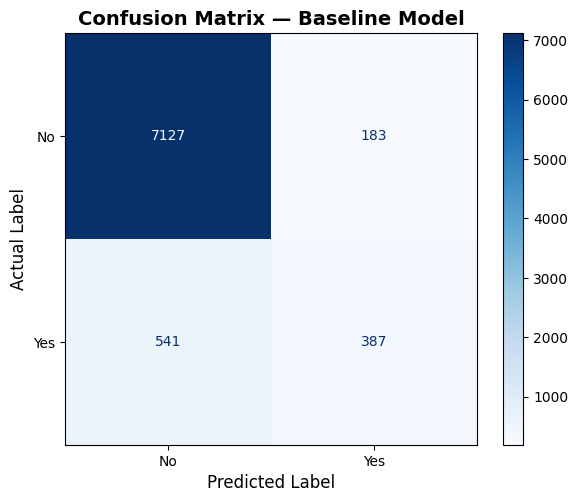

In [ ]:
# Visualise the confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_title('Confusion Matrix — Baseline Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

### 5.2 Accuracy, Precision, Recall, F1-Score

Now we compute the four core classification metrics from the confusion matrix values above.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('═' * 50)
print('        BASELINE MODEL METRICS')
print('═' * 50)
print(f'  Accuracy:   {accuracy:.4f}  — {accuracy:.1%} of all predictions correct')
print(f'  Precision:  {precision:.4f}  — {precision:.1%} of "subscribe" predictions were right')
print(f'  Recall:     {recall:.4f}  — {recall:.1%} of actual subscribers were caught')
print(f'  F1-Score:   {f1:.4f}  — Harmonic mean of precision and recall')
print('═' * 50)

══════════════════════════════════════════════════
        BASELINE MODEL METRICS
══════════════════════════════════════════════════
  Accuracy:   0.9121  — 91.2% of all predictions correct
  Precision:  0.6789  — 67.9% of "subscribe" predictions were right
  Recall:     0.4170  — 41.7% of actual subscribers were caught
  F1-Score:   0.5167  — Harmonic mean of precision and recall
══════════════════════════════════════════════════


**Interpreting these results:**

- **High accuracy** is misleading here — a model that always predicts "no subscribe" would achieve ~89% accuracy simply by exploiting the class imbalance. Our model needs to do better than this naive baseline.
- **Precision** tells us how trustworthy the model's positive predictions are. If precision is low, many clients flagged as "will subscribe" actually will not — this wastes the bank's calling resources.
- **Recall** (also called **sensitivity**) tells us what fraction of actual subscribers the model catches. If recall is low, the bank is missing potential customers who would have subscribed if contacted.
- **F1-Score** is the **harmonic mean** of precision and recall. It gives a single number that penalises extreme imbalances between the two — a model with 95% precision but 5% recall gets a very low F1. This makes F1 a better summary metric than accuracy for imbalanced datasets.

**The key tension for the bank:** Improving recall (catching more subscribers) typically comes at the cost of precision (more false alarms), and vice versa. The threshold tuning in Section 7 will let us control this trade-off explicitly.

### 5.3 Classification Report

The classification report from scikit-learn gives precision, recall, and F1 **per class** (not just for the positive class). This is useful because it shows how the model performs on *both* classes simultaneously. The `support` column shows how many test samples belong to each class. The `macro avg` treats both classes equally, while `weighted avg` weights by class size.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['No Subscribe', 'Subscribe']))

              precision    recall  f1-score   support

No Subscribe       0.93      0.97      0.95      7310
   Subscribe       0.68      0.42      0.52       928

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



### 5.4 ROC Curve and AUC

The **ROC (Receiver Operating Characteristic) curve** is one of the most important evaluation tools for binary classifiers. Unlike accuracy, precision, and recall, which depend on a single threshold (default 0.5), the ROC curve shows the model's performance **across all possible thresholds**, from 0 to 1.

**How to read the ROC curve:**
- The **x-axis** is the False Positive Rate (FPR) = FP / (FP + TN) — the proportion of non-subscribers incorrectly flagged
- The **y-axis** is the True Positive Rate (TPR, = Recall) = TP / (TP + FN) — the proportion of actual subscribers correctly caught
- Each point on the curve represents a different decision threshold
- The **dashed diagonal line** represents a random classifier (AUC = 0.5) — one that has no discriminative ability
- A **perfect classifier** would reach the top-left corner (FPR = 0, TPR = 1), giving AUC = 1.0

**The AUC (Area Under the Curve)** summarises the entire ROC curve as a single number between 0.5 and 1.0. It can be interpreted as: *"If we pick one random subscriber and one random non-subscriber, the AUC is the probability that the model assigns a higher predicted probability to the subscriber."*

| AUC Range | Interpretation |
|---|---|
| 0.90 – 1.00 | Excellent |
| 0.80 – 0.90 | Good |
| 0.70 – 0.80 | Fair |
| 0.50 – 0.70 | Poor (barely better than random) |

**Why AUC is useful:** Because it is **threshold-independent**, AUC is ideal for comparing different models or different hyperparameter settings fairly, without being biased by a particular threshold choice.

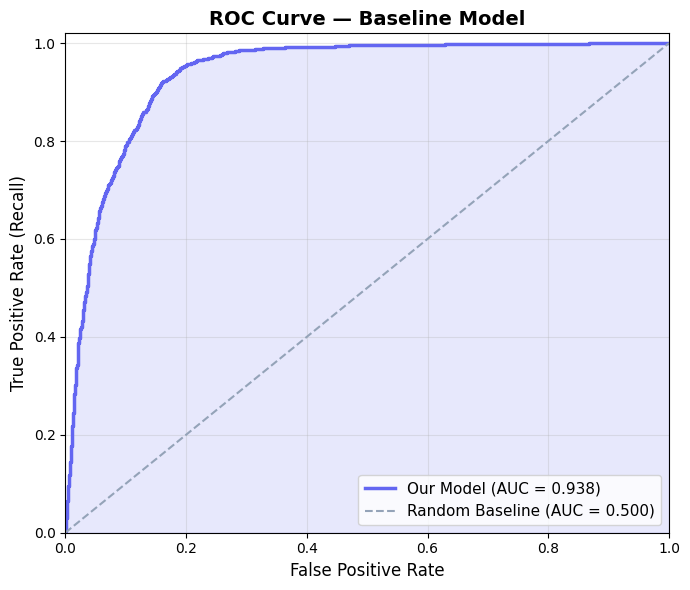

AUC-ROC Score: 0.9376
An AUC of 0.5 = random guessing, 1.0 = perfect classifier.


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#6366F1', linewidth=2.5, label=f'Our Model (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--', linewidth=1.5, label='Random Baseline (AUC = 0.500)')

ax.fill_between(fpr, tpr, alpha=0.15, color='#6366F1')

ax.set_title('ROC Curve — Baseline Model', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'AUC-ROC Score: {auc_score:.4f}')
print('An AUC of 0.5 = random guessing, 1.0 = perfect classifier.')

## 6. Hyperparameter Tuning with Grid Search

The baseline model used default hyperparameters. But are these the best settings for our specific dataset? **Hyperparameter tuning** is the process of systematically searching for the combination of settings that produces the best performance.

We focus on two hyperparameters:
- **C** (inverse regularisation strength): Controls how much the model is penalised for having large weights. Small C = strong regularisation (simpler model, risk of underfitting). Large C = weak regularisation (complex model, risk of overfitting).
- **Penalty type** (L1 vs L2): L1 (Lasso) can push some weights exactly to zero, performing automatic feature selection. L2 (Ridge) shrinks all weights towards zero but never eliminates features entirely.

**Why not just evaluate on the test set?** If we tried every combination of C and penalty on the test set and picked the best one, we would be overfitting to the test set — the test set is supposed to be used **only once** for final evaluation. Instead, we use **cross-validation** on the training set: the training data is split into 5 folds, and for each hyperparameter combination, the model is trained on 4 folds and validated on the remaining fold. This is repeated 5 times, and the average validation score tells us which combination generalises best.

The table below shows our hyperparameter grid. GridSearchCV will try **every combination** (4 values of C × 2 penalty types = 8 combinations), each evaluated with 5-fold cross-validation, giving **40 model fits** in total.

| Hyperparameter | What it controls | Values to try |
|---|---|---|
| **C** | Inverse regularisation strength | 0.01, 0.1, 1.0, 10 |
| **penalty** | Type of regularisation | L1 (Lasso), L2 (Ridge) |

We score using **F1** rather than accuracy because our dataset is imbalanced — F1 gives a more honest assessment of how well the model detects the minority class (subscribers).

### 6.1 Define the Grid and Run the Search

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0, 10],
    'penalty': ['l1', 'l2'],
}

# Note: L1 requires solver='liblinear' or 'saga'
# We use 'liblinear' as it supports both L1 and L2
base_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Run Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',         # Use F1 because our data is imbalanced
    return_train_score=True,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f'\nGrid Search complete!')
print(f'  Total combinations tested: {len(grid_search.cv_results_["params"])}')
print(f'  Total fits: {len(grid_search.cv_results_["params"])} combos × 5 folds = {len(grid_search.cv_results_["params"]) * 5}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Grid Search complete!
  Total combinations tested: 8
  Total fits: 8 combos × 5 folds = 40


### 6.2 Examine the Results

The table below shows every hyperparameter combination tested, sorted by rank. Key columns to examine:
- **Mean CV F1**: The average F1-Score across the 5 folds — this is our primary criterion
- **Std CV F1**: The standard deviation across folds — lower is better (more stable)
- **Mean Train F1**: The F1 on the training folds — if this is much higher than CV F1, the model may be overfitting

The line chart visualises how F1 changes with C for both L1 and L2 penalties. The shaded region shows ±1 standard deviation, indicating how stable the estimate is across folds.

In [ ]:
# View all results as a nice table
results = pd.DataFrame(grid_search.cv_results_)

# Select and rename the most useful columns
results_clean = results[['param_C', 'param_penalty', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']]
results_clean.columns = ['C', 'Penalty', 'Mean CV F1', 'Std CV F1', 'Mean Train F1', 'Rank']
results_clean = results_clean.sort_values('Rank')

print('Grid Search Results (sorted by rank):')
print('=' * 70)
print(results_clean.to_string(index=False))

Grid Search Results (sorted by rank):
    C Penalty  Mean CV F1  Std CV F1  Mean Train F1  Rank
 1.00      l1    0.515440   0.016069       0.521593     1
10.00      l1    0.514674   0.016540       0.522464     2
10.00      l2    0.514587   0.016481       0.522464     3
 1.00      l2    0.514374   0.015667       0.520850     4
 0.10      l1    0.510987   0.023083       0.512758     5
 0.10      l2    0.506799   0.023789       0.513517     6
 0.01      l2    0.496168   0.023282       0.497832     7
 0.01      l1    0.483545   0.022990       0.483132     8


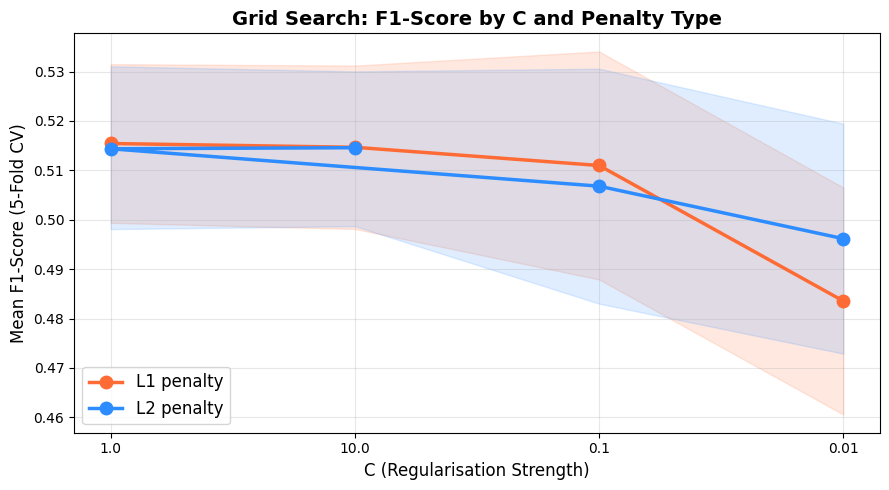

In [ ]:
# Visualise the grid search results
fig, ax = plt.subplots(figsize=(9, 5))

# Pivot the results for plotting
for penalty in ['l1', 'l2']:
    mask = results_clean['Penalty'] == penalty
    subset = results_clean[mask]
    colour = '#2D8CFF' if penalty == 'l2' else '#FF6B35'
    ax.plot(subset['C'].astype(str), subset['Mean CV F1'],
            marker='o', linewidth=2.5, markersize=9, label=f'{penalty.upper()} penalty', color=colour)
    # Add error bars
    ax.fill_between(range(len(subset)),
                    subset['Mean CV F1'].values - subset['Std CV F1'].values,
                    subset['Mean CV F1'].values + subset['Std CV F1'].values,
                    alpha=0.15, color=colour)

ax.set_xlabel('C (Regularisation Strength)', fontsize=12)
ax.set_ylabel('Mean F1-Score (5-Fold CV)', fontsize=12)
ax.set_title('Grid Search: F1-Score by C and Penalty Type', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Best Hyperparameters

GridSearchCV automatically identifies the combination with the highest mean cross-validation F1-Score. The best model is already retrained on the full training set and stored in `grid_search.best_estimator_`.

In [ ]:
print('═' * 50)
print('        BEST HYPERPARAMETERS')
print('═' * 50)
print(f'  Best C:       {grid_search.best_params_["C"]}')
print(f'  Best Penalty: {grid_search.best_params_["penalty"]}')
print(f'  Best F1 (CV): {grid_search.best_score_:.4f}')
print('═' * 50)

# The best model is already trained and accessible
best_model = grid_search.best_estimator_

══════════════════════════════════════════════════
        BEST HYPERPARAMETERS
══════════════════════════════════════════════════
  Best C:       1.0
  Best Penalty: l1
  Best F1 (CV): 0.5154
══════════════════════════════════════════════════


### 6.4 Evaluate the Tuned Model on the Test Set

Now we evaluate the tuned model on the **held-out test set** — data the model has never seen during training or hyperparameter selection. This gives us an honest, unbiased estimate of real-world performance. We compare every metric side-by-side with the baseline to see whether tuning actually helped.

In [ ]:
# Predictions with the best model
y_pred_tuned = best_model.predict(X_test_scaled)
y_pred_proba_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

accuracy_tuned  = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned    = recall_score(y_test, y_pred_tuned)
f1_tuned        = f1_score(y_test, y_pred_tuned)
auc_tuned       = roc_auc_score(y_test, y_pred_proba_tuned)

# Compare baseline vs tuned
print('═' * 60)
print('        BASELINE vs TUNED MODEL (Test Set)')
print('═' * 60)
print(f'{"Metric":<15} {"Baseline":>10} {"Tuned":>10} {"Change":>10}')
print('─' * 60)
print(f'{"Accuracy":<15} {accuracy:>10.4f} {accuracy_tuned:>10.4f} {accuracy_tuned - accuracy:>+10.4f}')
print(f'{"Precision":<15} {precision:>10.4f} {precision_tuned:>10.4f} {precision_tuned - precision:>+10.4f}')
print(f'{"Recall":<15} {recall:>10.4f} {recall_tuned:>10.4f} {recall_tuned - recall:>+10.4f}')
print(f'{"F1-Score":<15} {f1:>10.4f} {f1_tuned:>10.4f} {f1_tuned - f1:>+10.4f}')
print(f'{"AUC-ROC":<15} {auc_score:>10.4f} {auc_tuned:>10.4f} {auc_tuned - auc_score:>+10.4f}')
print('═' * 60)

════════════════════════════════════════════════════════════
        BASELINE vs TUNED MODEL (Test Set)
════════════════════════════════════════════════════════════
Metric            Baseline      Tuned     Change
────────────────────────────────────────────────────────────
Accuracy            0.9121     0.9119    -0.0002
Precision           0.6789     0.6772    -0.0018
Recall              0.4170     0.4159    -0.0011
F1-Score            0.5167     0.5154    -0.0013
AUC-ROC             0.9376     0.9375    -0.0001
════════════════════════════════════════════════════════════


## 7. Optimising the Decision Threshold

So far, our model has used the default threshold of **0.5**: if the predicted probability of subscribing is ≥ 0.5, predict "yes"; otherwise predict "no". But this threshold is arbitrary — it was not chosen based on our data or our business priorities.

**Why change the threshold?**

Lowering the threshold (e.g. to 0.3) means the model will predict "subscribe" more often. This **increases recall** (catches more actual subscribers) but **decreases precision** (more false alarms). Raising the threshold (e.g. to 0.7) has the opposite effect — fewer but more confident positive predictions.

The optimal threshold depends on the **business context**:
- If missing a subscriber costs the bank more than a wasted phone call → **lower the threshold** (prioritise recall)
- If calling non-subscribers is very expensive or annoying → **raise the threshold** (prioritise precision)
- If you want a balanced trade-off → **choose the threshold that maximises F1-Score**

The code below sweeps through thresholds from 0.10 to 0.85 in steps of 0.05, computing precision, recall, and F1-Score at each. The resulting table and chart show exactly how the three metrics trade off against each other as the threshold changes.

**How to read the chart:**
- The **Precision curve** (blue) rises as the threshold increases — the model only predicts "subscribe" when very confident, so those predictions tend to be correct
- The **Recall curve** (orange) falls as the threshold increases — a higher bar means fewer clients are flagged, so more actual subscribers are missed
- The **F1 curve** (green) peaks at the threshold where precision and recall are best balanced
- The **dashed green line** marks the threshold that maximises F1

In [ ]:
# Test a range of thresholds
thresholds_to_try = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for t in thresholds_to_try:
    # Apply the threshold to probabilities
    y_pred_t = (y_pred_proba_tuned >= t).astype(int)

    # Compute metrics
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t)
    f1_t   = f1_score(y_test, y_pred_t)

    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': round(prec_t, 4),
        'Recall': round(rec_t, 4),
        'F1': round(f1_t, 4)
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

 Threshold  Precision  Recall     F1
      0.10     0.4247  0.9116 0.5795
      0.15     0.4672  0.8276 0.5972
      0.20     0.5154  0.7597 0.6141
      0.25     0.5640  0.6983 0.6240
      0.30     0.5972  0.6358 0.6159
      0.35     0.6321  0.5722 0.6007
      0.40     0.6345  0.5108 0.5660
      0.45     0.6541  0.4666 0.5447
      0.50     0.6772  0.4159 0.5154
      0.55     0.6859  0.3718 0.4822
      0.60     0.6956  0.3200 0.4384
      0.65     0.6995  0.2759 0.3957
      0.70     0.6966  0.2425 0.3597
      0.75     0.6885  0.1929 0.3013
      0.80     0.6796  0.1509 0.2469
      0.85     0.6774  0.1131 0.1939


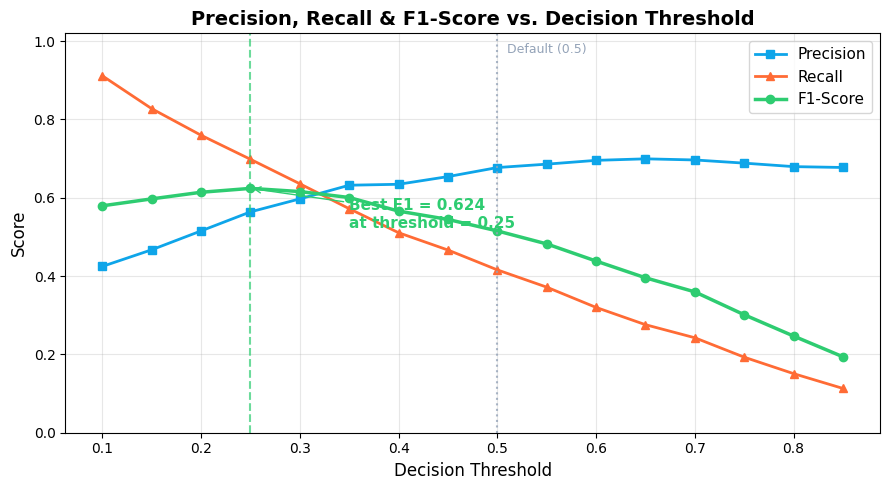

In [ ]:
# Visualise the precision-recall-F1 trade-off
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(threshold_df['Threshold'], threshold_df['Precision'],
        marker='s', linewidth=2, label='Precision', color='#0EA5E9')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'],
        marker='^', linewidth=2, label='Recall', color='#FF6B35')
ax.plot(threshold_df['Threshold'], threshold_df['F1'],
        marker='o', linewidth=2.5, label='F1-Score', color='#2ECC71')

# Mark the best F1 threshold
best_idx = threshold_df['F1'].idxmax()
best_t = threshold_df.loc[best_idx, 'Threshold']
best_f1_val = threshold_df.loc[best_idx, 'F1']
ax.axvline(x=best_t, color='#2ECC71', linestyle='--', alpha=0.7)
ax.annotate(f'Best F1 = {best_f1_val:.3f}\nat threshold = {best_t}',
            xy=(best_t, best_f1_val), xytext=(best_t + 0.1, best_f1_val - 0.1),
            fontsize=11, fontweight='bold', color='#2ECC71',
            arrowprops=dict(arrowstyle='->', color='#2ECC71'))

# Mark default threshold
ax.axvline(x=0.5, color='#94A3B8', linestyle=':', alpha=0.8)
ax.text(0.51, 0.95, 'Default (0.5)', color='#94A3B8', fontsize=9, transform=ax.get_xaxis_transform())

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall & F1-Score vs. Decision Threshold', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

### 7.1 Final Model with Optimised Threshold

We now apply the best threshold and compare the **full pipeline** (GridSearch + Threshold) against the baseline. The three-column comparison below shows how each tuning step contributed to the overall improvement.

The **side-by-side confusion matrices** are particularly informative — look at how the number of False Negatives (missed subscribers) changes between the baseline and the tuned model. This is the most direct way to see the practical impact of threshold tuning:

- **Baseline matrix (left):** Uses default threshold = 0.5 with default hyperparameters
- **Tuned matrix (right):** Uses optimised C, penalty, and threshold

Compare the **bottom-left cell** (FN) in both matrices: a reduction here means the tuned model is catching more actual subscribers. Also compare the **top-right cell** (FP): an increase here is the "price" we pay for better recall. The bank must decide whether the additional subscribers caught are worth the extra false alarms.

In [ ]:
# Apply the best threshold
y_pred_final = (y_pred_proba_tuned >= best_t).astype(int)

accuracy_final  = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final    = recall_score(y_test, y_pred_final)
f1_final        = f1_score(y_test, y_pred_final)

print('═' * 70)
print('    BASELINE  vs  TUNED (C & penalty)  vs  TUNED + THRESHOLD')
print('═' * 70)
print(f'{"Metric":<15} {"Baseline":>12} {"+ GridSearch":>14} {"+ Threshold":>14}')
print('─' * 70)
print(f'{"Accuracy":<15} {accuracy:>12.4f} {accuracy_tuned:>14.4f} {accuracy_final:>14.4f}')
print(f'{"Precision":<15} {precision:>12.4f} {precision_tuned:>14.4f} {precision_final:>14.4f}')
print(f'{"Recall":<15} {recall:>12.4f} {recall_tuned:>14.4f} {recall_final:>14.4f}')
print(f'{"F1-Score":<15} {f1:>12.4f} {f1_tuned:>14.4f} {f1_final:>14.4f}')
print('═' * 70)
print(f'\nFinal model: C={grid_search.best_params_["C"]}, '
      f'penalty={grid_search.best_params_["penalty"]}, '
      f'threshold={best_t}')

══════════════════════════════════════════════════════════════════════
    BASELINE  vs  TUNED (C & penalty)  vs  TUNED + THRESHOLD
══════════════════════════════════════════════════════════════════════
Metric              Baseline   + GridSearch    + Threshold
──────────────────────────────────────────────────────────────────────
Accuracy              0.9121         0.9119         0.9052
Precision             0.6789         0.6772         0.5640
Recall                0.4170         0.4159         0.6983
F1-Score              0.5167         0.5154         0.6240
══════════════════════════════════════════════════════════════════════

Final model: C=1.0, penalty=l1, threshold=0.25


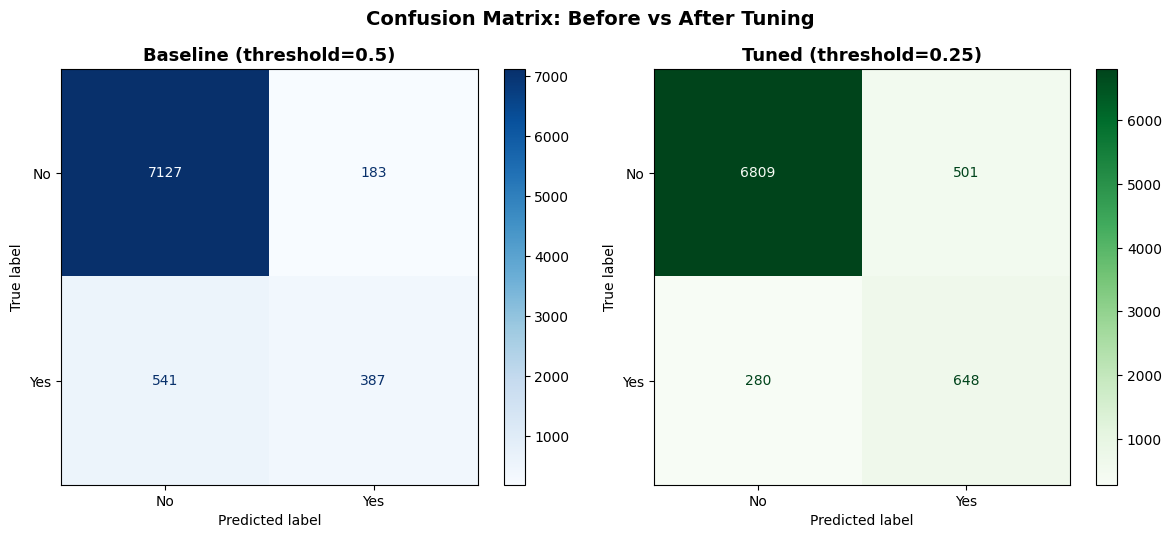

In [ ]:
# Final confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes']).plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Baseline (threshold=0.5)', fontsize=13, fontweight='bold')

# Final
ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['No', 'Yes']).plot(cmap='Greens', ax=axes[1], values_format='d')
axes[1].set_title(f'Tuned (threshold={best_t})', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix: Before vs After Tuning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Importance

One of the key advantages of logistic regression over more complex models (such as neural networks or ensemble methods) is its **interpretability**. Each feature receives a coefficient (weight) that directly tells us how it influences the prediction.

The bar chart below shows the **top 15 features** ranked by the absolute value of their coefficient in the tuned model:

- **Green (positive coefficient):** As this feature increases, the predicted probability of subscribing increases. For example, if `duration` has a large positive coefficient, longer phone calls are associated with higher subscription rates.
- **Red (negative coefficient):** As this feature increases, the predicted probability of subscribing decreases. For example, a negative coefficient for `nr_employed` might indicate that when national employment is high, clients are less likely to subscribe (perhaps they feel less need for savings products).

**Important caveats:**
- Because we scaled the numeric features, the coefficients are **comparable** in magnitude — a coefficient of 0.8 genuinely indicates more influence than one of 0.2.
- One-hot encoded categories should be interpreted relative to the **dropped reference category** (the one removed by `drop_first=True`). For instance, `contact_telephone` being negative means telephone contact reduces subscription probability *compared to* the reference category (cellular).
- Coefficients show **association**, not necessarily causation. The `duration` feature, for example, is known after the call ends, so it cannot be used to predict outcomes before making the call.

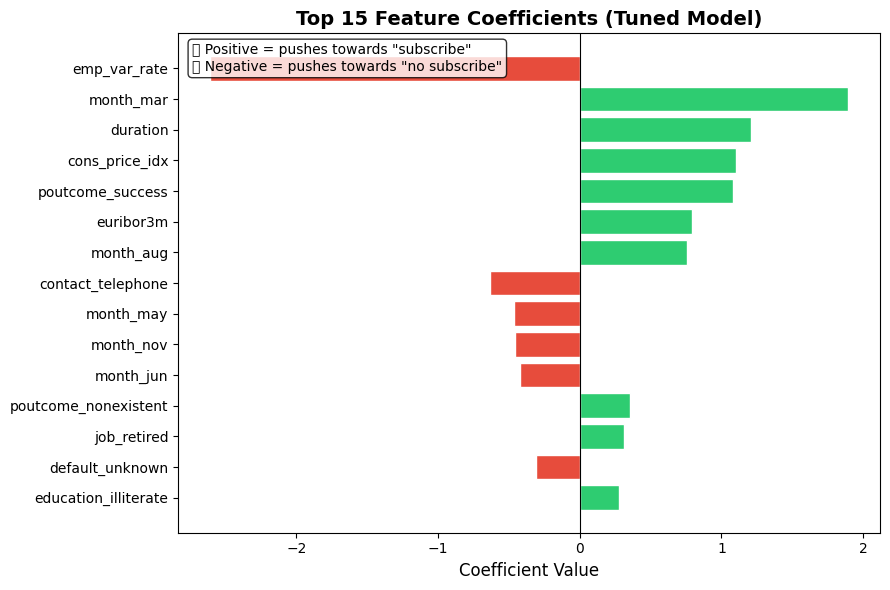

In [ ]:
# Extract and sort feature importances (coefficients)
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': best_model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

# Plot top 15 features
top_features = coef_df.head(15)

fig, ax = plt.subplots(figsize=(9, 6))

colours = ['#2ECC71' if c > 0 else '#E74C3C' for c in top_features['Coefficient']]
ax.barh(range(len(top_features)), top_features['Coefficient'], color=colours, edgecolor='white')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()

ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Top 15 Feature Coefficients (Tuned Model)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Legend
ax.text(0.02, 0.98, '🟢 Positive = pushes towards "subscribe"\n🔴 Negative = pushes towards "no subscribe"',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

---

## Exercises

Now it's your turn! Complete the following exercises to consolidate your understanding of the complete pipeline we have built. Each exercise targets a different aspect of the workflow — from interpreting outputs to modifying the pipeline and making business recommendations.

### Exercise 1: Interpret the Confusion Matrix

Look at the **final tuned model's confusion matrix** above and answer the following questions in a text cell:

1. How many clients did the model **correctly identify** as subscribers?
2. How many clients were **wrongly flagged** as subscribers (false positives)?
3. How many actual subscribers did the model **miss** (false negatives)?
4. From a business perspective, which error is more costly for the bank — false positives or false negatives? Why?

In [ ]:
# Write your answers here as comments or in a text cell below

# 1.
# 2.
# 3.
# 4.


### Exercise 2: Manual Metric Calculation

Using the confusion matrix values from the **baseline model** (Section 5.1), manually calculate:
- Accuracy
- Precision
- Recall
- F1-Score

Then verify your answers using the variables we computed.

In [ ]:
# The confusion matrix values from the baseline model are:
print(f'TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}')
print()

# Calculate each metric manually (replace the ... with your formulas)
my_accuracy  = ...  # (TP + TN) / (TP + TN + FP + FN)
my_precision = ...  # TP / (TP + FP)
my_recall    = ...  # TP / (TP + FN)
my_f1        = ...  # 2 * (precision * recall) / (precision + recall)

# Uncomment to check your answers:
# print(f'My Accuracy:  {my_accuracy:.4f}  (scikit-learn: {accuracy:.4f})')
# print(f'My Precision: {my_precision:.4f}  (scikit-learn: {precision:.4f})')
# print(f'My Recall:    {my_recall:.4f}  (scikit-learn: {recall:.4f})')
# print(f'My F1:        {my_f1:.4f}  (scikit-learn: {f1:.4f})')

### Exercise 3: Expand the Grid Search

Our grid search was deliberately small. Try expanding it:

1. Add more values of `C` (e.g. `0.001`, `50`, `100`)
2. Change the scoring metric to `'recall'` instead of `'f1'`
3. Run the new grid search and compare the best parameters

**Question:** How do the best hyperparameters change when you optimise for recall instead of F1? Why?

In [ ]:
# Your expanded grid search here

# param_grid_expanded = {
#     'C': [...],           # Add more values
#     'penalty': ['l1', 'l2'],
# }

# grid_search_expanded = GridSearchCV(
#     estimator=LogisticRegression(solver='liblinear', random_state=42, max_iter=1000),
#     param_grid=param_grid_expanded,
#     cv=5,
#     scoring='recall',     # <-- Changed from 'f1'
#     verbose=1
# )

# grid_search_expanded.fit(X_train_scaled, y_train)
# print(f'Best params (recall): {grid_search_expanded.best_params_}')
# print(f'Best recall (CV):     {grid_search_expanded.best_score_:.4f}')

### Exercise 4: Threshold for Different Business Goals

Using the `y_pred_proba_tuned` probabilities, apply two different thresholds and compare the results:

- **Threshold = 0.3** (aggressive: catch as many subscribers as possible)
- **Threshold = 0.7** (conservative: only predict 'subscribe' when very confident)

For each, compute precision, recall, and F1-Score. Which threshold would you recommend to the bank, and why?

In [ ]:
# Threshold = 0.3
# y_pred_03 = (y_pred_proba_tuned >= 0.3).astype(int)
# print('Threshold = 0.3')
# print(f'  Precision: {precision_score(y_test, y_pred_03):.4f}')
# print(f'  Recall:    {recall_score(y_test, y_pred_03):.4f}')
# print(f'  F1-Score:  {f1_score(y_test, y_pred_03):.4f}')

# Threshold = 0.7
# y_pred_07 = (y_pred_proba_tuned >= 0.7).astype(int)
# print('\nThreshold = 0.7')
# print(f'  Precision: {precision_score(y_test, y_pred_07):.4f}')
# print(f'  Recall:    {recall_score(y_test, y_pred_07):.4f}')
# print(f'  F1-Score:  {f1_score(y_test, y_pred_07):.4f}')

# Your recommendation:
# ...

### Exercise 5: Feature Impact Analysis

Look at the feature importance chart in Section 8.

1. Identify the **top 3 features** that increase the probability of subscription.
2. Identify the **top 3 features** that decrease the probability of subscription.
3. If you were a marketing manager at the bank, how would you use these insights to improve the next campaign?

Write your answers in the cell below.

In [ ]:
# Write your answers here as comments

# 1. Top 3 features increasing subscription probability:
# 2. Top 3 features decreasing subscription probability:
# 3. Marketing recommendations:
